In [1]:
import pandas as pd

# Load the Math dataset
# We use sep=';' because the data uses semicolons instead of commas
math_data = pd.read_csv('student-mat.csv', sep=';')

# This shows us the first 5 rows and all the columns available[cite: 1]
print("Dataset Loaded Successfully!")
math_data.head()

Dataset Loaded Successfully!


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
# Load the Portuguese dataset
por_data = pd.read_csv('student-por.csv', sep=';')

# Combine both datasets into one big table (DataFrame)[cite: 1, 2]
# This stacks the Math and Portuguese students on top of each other
df = pd.concat([math_data, por_data], axis=0).reset_index(drop=True)

# Let's check for "Missing Values"
# ML models break if there are empty spots in the data.
print("Checking for missing values:")
print(df.isnull().sum().sum())

# Let's see how many rows and columns we have now
print(f"\nTotal students in our combined dataset: {df.shape[0]}")

Checking for missing values:
0

Total students in our combined dataset: 1044


In [3]:
# 1. Define our Target (what we want to predict)
y = df['G3']

# 2. Define our Features (what we use to predict)
# We drop G1 and G2 to make it a more impressive "behavioral" prediction.
# We drop G3 because we can't use the answer to predict the answer!
X = df.drop(columns=['G1', 'G2', 'G3'])

# 3. Convert text (Categorical data) into numbers
# This turns 'sex' (F/M) into 'sex_M' (0/1), etc.
X = pd.get_dummies(X, drop_first=True)

# 4. Split the data into "Training" and "Testing"
# We give 80% of the data to the AI to "study"
# and keep 20% hidden to "test" it later.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Preprocessing Complete!")
print(f"Features for training: {X_train.shape[1]} columns")
print(f"Number of students in training set: {X_train.shape[0]}")

Preprocessing Complete!
Features for training: 39 columns
Number of students in training set: 835


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Create the model "brain"
lr_model = LinearRegression()

# 2. Training: The AI looks at X (habits) and y (grades) to find a pattern
lr_model.fit(X_train, y_train)

# 3. Prediction: We ask the AI to guess the grades for the students it HAS NOT seen (X_test)
lr_predictions = lr_model.predict(X_test)

# 4. Scoring: How close was the AI?
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Trained!")
print(f"On average, the AI's guess is off by: {lr_mae:.2f} points")
print(f"R2 Score (Model Accuracy): {lr_r2:.2f}")

Linear Regression Trained!
On average, the AI's guess is off by: 2.64 points
R2 Score (Model Accuracy): 0.09


In [5]:
from sklearn.ensemble import RandomForestRegressor

# 1. Create the "Forest" (we use 100 trees)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Training the Forest
rf_model.fit(X_train, y_train)

# 3. Asking the Forest to predict the same test students
rf_predictions = rf_model.predict(X_test)

# 4. Scoring the Forest
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Trained!")
print(f"Random Forest MAE: {rf_mae:.2f}")
print(f"Random Forest R2 Score: {rf_r2:.2f}")

Random Forest Trained!
Random Forest MAE: 2.63
Random Forest R2 Score: 0.11


/tmp/ipykernel_8597/404343528.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


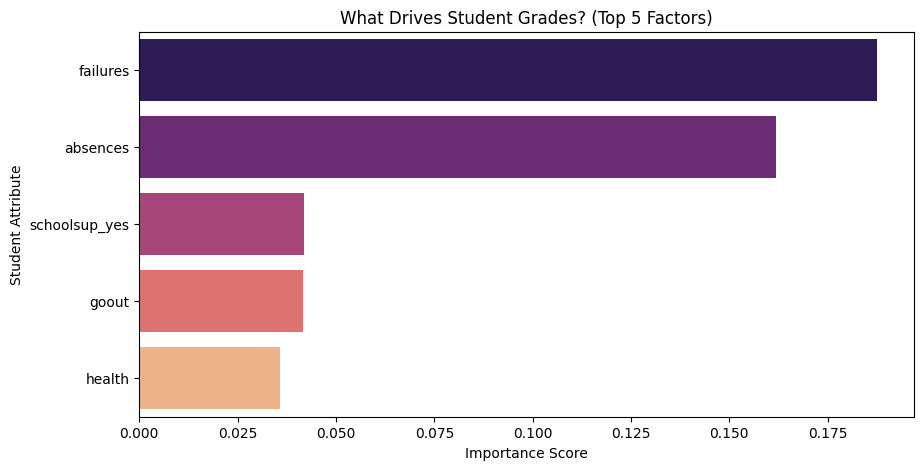

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the importance of each feature from your Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Organize them into a table
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

# Create the visual chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('What Drives Student Grades? (Top 5 Factors)')
plt.xlabel('Importance Score')
plt.ylabel('Student Attribute')
plt.show()